# Progetto 2: canale di Pauli

In questo progetto implementeremo il **canale di Pauli** generale in qiskit. 

Come applicazione, calcoleremo una quantità molto importante in termodinamica quantistica, nota come lavoro estraibile, cercando di riprodurre il risultato dell'articolo [*G. García-Pérez et al., npj Quantum Inf 6, 1 (2020)*](https://doi.org/10.1038/s41534-019-0235-y).

Il sistema quantistico aperto a singolo qubit più generale è il canale di Pauli dipendente dal tempo. L'equazione maestra in questo caso prende la forma 
\begin{equation}
\frac{d\rho_{S} }{dt}(t)=\frac{1}{2}\sum_i\gamma_i(t)\left[\sigma_i\rho_{S}(t)\sigma_i-\rho_{S}(t)\right].
\end{equation}

In generale, la dinamica descritta dall’equazione maestra sopra riportata non è covariante rispetto alla fase [[1](#1)], tranne nel caso in cui $\gamma_x(t)=\gamma_y(t)$. Inoltre, poiché i rate di decadimento possono assumere valori negativi, è necessario imporre condizioni di completa positività, che sono espresse in termini di un insieme di disuguaglianze che coinvolgono tutti e tre i rate di decadimento, come si può vedere, ad esempio, dalla referenza [[2](#2)].
<!--
**In Sec.~\ref{sec:discussion} we present the simulation of a specific form of time-dependent Pauli channel proposed in Ref.~\cite{Hall2014} and used as an example of eternal non-Markovianity, i.e.~an open quantum system dynamics for which the dynamical map is non-CP-divisible for all times $t$. More precisely, we use this experimental simulation to demonstrate a phenomenon predicted in Ref.~\cite{BognaWork}, namely the presence of oscillations in the extractable work. This shows an application of open quantum system simulation on the IBM Q Experience processors to fields other than quantum information theory, specifically quantum thermodynamics for the example here considered.** What? Is example Markovian or non-Markovian???? -->

A uno specifico istante temporale $t$, il canale di Pauli può essere scritto come
\begin{equation} 
 \mathcal{E} (\rho) = \sum_{i=0}^3 p_i \sigma_i \rho \sigma_i,
\end{equation}
 
con $0 \leq p_i \leq 1$ e $\sum_i p_i = 1$. Il canale di depolarizzazione è un caso specifico del canale di Pauli dove $p_1 = p_2 = p_3 = p/4$. 

È possibile implementare il canale di Pauli generale utilizzando solo due qubit ausiliari, preparandoli in un adeguato stato di entanglement. Il primo qubit funge da controllo per un gate $X$ controllato (CNOT), mentre il secondo per un gate $Y$ controllato. Si noti che l'applicazione combinata di un gate $X$ e di un gate $Y$ equivale, in pratica, all'applicazione di un gate $Z$.

Lo stato $|\psi \rangle$ dei qubit ausiliari necessario per il canale di Pauli può essere implementato dal circuito seguente:

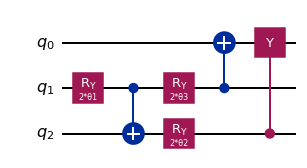

In [7]:
from qiskit import QuantumRegister, QuantumCircuit
from qiskit.circuit import Parameter

#############################
#       canale di Pauli     #
#############################

# Quantum register
q = QuantumRegister(3, name="q")

# Quantum circuit
pauli = QuantumCircuit(q)

# canale di Pauli che agisce su q_2
## Qubit identification
system = 0
a_0 = 1
a_1 = 2

# ## Definire gli angoli di rotazione
theta_1 = Parameter('θ1')
theta_2 = Parameter('θ2')
theta_3 = Parameter('θ3')

## Costruire il circuito
pauli.ry(2*theta_1, q[a_0])
pauli.cx(q[a_0], q[a_1])
pauli.ry(2*theta_3, q[a_0])
pauli.ry(2*theta_2, q[a_1])
pauli.cx(q[a_0], q[system])
pauli.cy(q[a_1], q[system])

# Disegnare il circuito
pauli.draw(output='mpl')

## Attività 1 (1 punto)

Il canale di depolarizzazione è un caso specifico del canale di Pauli dove $p_1 = p_2 = p_3 = p/4$. Può quindi essere implementato usando il circuito sopra. Ma perché un generico canale di Pauli non può essere implementato con il circuito usato nel Progetto 1, se permettiamo ai ciacuno dei tre qubit ausiliari di essere ruotato di un diverso angolo $\theta$?

Trova un controesempio del canale di Pauli che non può essere implementato con il circuito usato nel Progetto 1.

## Attività 2 (2 punti)
La parte cruciale dell'implementazione del circuito per il canale di Pauli è l'inversione del sistema di equazioni

\begin{equation}
    \begin{cases}
        p_0  = |\langle 00|\psi \rangle|^2 = (c_1 c_2 c_3 + s_1 s_2 s_3)^2 & \\
        p_1  = |\langle 01|\psi \rangle|^2 = (c_1 c_2 s_3 - s_1 s_2 c_3)^2 & \\
        p_2  = |\langle 10|\psi \rangle|^2 = (c_1 s_2 c_3 - s_1 c_2 s_3)^2 & \\
        p_3  = |\langle 11|\psi \rangle|^2 = (s_1 c_2 c_3 + c_1 s_2 s_3)^2 &
    \end{cases}
\end{equation}

dove $c_i \equiv \cos \theta_i$ e $s_i \equiv \sin \theta_i$, che ci dà i tre angoli $\theta_1$, $\theta_2$ e $\theta_3$.


Il sistema ammette più soluzioni, ma ci basta trovarne una (possiamo limitarci agli angoli compresi tra 0 e $2\pi$).

1. *Trova una soluzione di questo tipo, sia analiticamente (ad esempio utilizzando Mathematica) sia numericamente (ad esempio utilizzando `scipy.optimize`)*
2. *Implementa una funzione che restituisca il circuito che implementa il canale di Pauli per una lista di valori `[p_1, p_2, p_3]`.*

NOTA: Molti risolutori non sono in grado di trovare una soluzione in modo coerente o non riescono affatto a trovare una soluzione per il punto 2.1. Può essere utile fornire una stima iniziale (ad esempio casuale) e consentire al risolutore solo soluzioni con una tolleranza molto bassa ($<10^{-10}$). Può anche essere utile fornire i limiti $(0, 2\pi)$ e passare da un algoritmo di minimizzazione all'altro.

In [ ]:
def pauli_channel(q, p, system, pauli_ancillae):
    """
        Applichiamo il canale di Pauli al sistema con probabilità p
        
    Args:
    q (QuantumRegister): il registro quantistico per il circuito
    system (int): indice del qubit del sistema
    pauli_ancillae (list): lista di indici dei qubit ausiliari
    p (list): lista di probabilità [p_1, p_2, p_3] per il canale di Pauli 
    
    Returns:
    Un QuantumCircuit che implementa il canale di Pauli 
    """
    
    # Write code

## Attività 3 (2 punti)

Misureremo la quantità di lavoro che può essere estratta tramite cancellazione nel nostro sistema, costituito dal qubit A preparato inizialmente in uno stato entangled con una memoria quantistica Q. Questa grandezza è rilevante nella termodinamica quantistica. È stata introdotta in *L. del Rio et al., Nature 474, 61 (2011)* e studiata anche nel contesto delle dinamiche non markoviane, [*B. Bylicka et al., Sci. Rep. 6, 27989 (2016)*](https://www.nature.com/articles/srep27989) (un’implementazione sperimentale su dispositivi IBM Q è disponibile qui: [*G. García-Pérez et al., npj Quantum Inf 6, 1 (2020)*](https://doi.org/10.1038/s41534-019-0235-y)).

Implementeremo una funzione che calcola l’equazione (4) di [*B. Bylicka et al., Sci. Rep. 6, 27989 (2016)*](https://www.nature.com/articles/srep27989). È possibile utilizzare il lavoro estraibile riscalato riportato di seguito.

$$\frac{W_{ex}(t)}{kT\ln{2}} = [n - S(A | Q)]$$

Per questo, abbiamo bisogno di una funzione `conditional_entropy` che prende in ingresso un vettore di stato a due qubit o operatore densità e dà come risultato l'entropia condizionata $S(A|B) = S(AB) - S(B)$ dove $S$ indica l'[entropia di von-Neumann](https://en.wikipedia.org/wiki/Von_Neumann_entropy).

In [ ]:
# Importazioni suggerite...
from qiskit.quantum_info import entropy, partial_trace

def conditional_entropy(state, qubit_a, qubit_b):
    """Entropia condizionata S(A|B) = S(AB) - S(B)
    
    Args:
        state: un vettore o l'operatore densità
        qubit_a: indice del qubit A (a partire da 0) 
        qubit_b: indice del qubit B (a partire da 0) 
        
    Returns:
        int: l'entropia condizionata
    """
    # Scrivere il codice qui

Ora puoi implementare la funzione `extractable_work`. Anche questa prende in ingresso un sistema a due qubit e restituisce la quantità di lavoro estraibile.

In [ ]:
def extractable_work(state, system_qubit, memory_qubit, n=1):
    """Lavoro estraibile da uno stato a due qubit
    =
    Cfr. Eq. (4) Bylicka et al., Sci. Rep. 6, 27989 (2016)
    
    Args:
        state: un vettore o l'operatore densità
        system_qubit: indice del qubit di sistema
        memory_qubit: indice del qubit di memoria
        n: numero di qubit di sistema
    """
    # Scrivere il codice qui

## Attività 4 (5 punti)

Ora implementeremo due diversi tipi di dinamiche, cioè funzioni che restituiscono i valori di p in funzione del tempo. Una è una mappa non-CP-divisible (vedi [Chapter 8 of Open Quantum Systems with Qiskit](https://matteoacrossi.github.io/open_quantum_systems_course/non-markovian_quantum_dynamics.html))

    p_ncp = [1/4 * (1 - np.exp(-2 * t * eta)), 
             1/4 * (1 - np.exp(-2 * t * eta)),
             1/4 * (1 + np.exp(-2 * t * eta) - 2 * np.exp(-t * eta) * np.cos(t * omega))]
             
e l'altra è eternamente non-Markoviana (vedi [*G. García-Pérez et al., npj Quantum Inf 6, 1 (2020)*](https://doi.org/10.1038/s41534-019-0235-y))

    p_enm = [1/4 * (1 - np.exp(-2 * t * eta)), 
             1/4 * (1 - np.exp(-2 * t * eta)),
             1/4 * (1 + np.exp(-2 * t * eta) - 2 * np.exp(-t * eta) * np.cosh(t * omega))]

1. Scrivi le funzioni `p_ncp(t)` e `p_enm(t)` che restituiscono il circuito che simula il canale di Pauli al tempo $t$ per le due dinamiche sopra indicate.
2. Scrivi un circuito in cui si preparano due qubit (il sistema e la memoria) nello stato $|\Psi^-\rangle = \frac{1}{\sqrt{2}}{(|01\rangle - |10\rangle)}$.
3. Utilizziamo la seguente scala temporale e i seguenti parametri per le dinamiche.


        t_values = np.linspace(0, 3, 11)

        params_ncp = {'eta': 0.1, 'omega': 2.0}
        params_enm = {'eta': 1.0, 'omega': 0.5}


    scrivi i circuiti che implementano le dinamiche per ciascuno dei `t_values`.
   
4. Per ciascun circuito, esegui la tomografia di stato su un simulatore, calcola e traccia il lavoro estraibile in funzione del tempo per entrambe le dinamiche. Esegui i circuiti utilizzando [`qiskit_experiments.framework.BatchExperiment`](https://qiskit.org/ecosystem/experiments/stubs/qiskit_experiments.framework.BatchExperiment.html#qiskit_experiments.framework.BatchExperiment) fornendo un elenco di istanze di `StateTomography`. In questo modo è possibile eseguire tutti i circuiti necessari con un’unica chiamata, il che può velocizzare gli esperimenti quando si ha a che fare, ad esempio, con dispositivi reali.
5. Traccia anche i valori esatti del lavoro estraibile per entrambe le dinamiche.


## Attività opzionale


1. Utilizza il circuito del canale di Pauli generale per implementare il canale di depolarizzazione su un dispositivo reale e confronta i risultati sperimentali con quelli del progetto precedente. Quale dei due presenta una fedeltà maggiore?

2. Esegui il codice sopra riportato su un dispositivo reale e confrontalo con la simulazione. Per assistenza, consulta la soluzione del progetto 1!